# Seismic P-Wave Detection with Deep Learning

This notebook trains and evaluates multiple 1-D Convolutional Neural Network (CNN) models
to classify seismic waveform windows as either **P-wave arrivals** (label = 1) or
**seismic noise** (label = 0) using the STEAD dataset (chunk2).


## Team Members Name
MD. Atiqur Rahman Sifat
Id- 0432410005101124

Muhammad Imtiaz Ahmed
Id-0432410005101138

Labib Ahmod
Id- 0432410005101133

Fahimda Fardousi
Id- 2215151132

In [1]:
# Section 1: Library imports

import h5py 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split  

# TensorFlow / Keras building blocks
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense,
    BatchNormalization, Dropout,
    Bidirectional, LSTM,
    GlobalAveragePooling1D,
    Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2  # Weight-decay regularisation

In [2]:
# Section 2: Load & inspect the metadata CSV
meta = pd.read_csv("chunk2.csv", low_memory=False)

print(f"Total records loaded: {len(meta):,}")
print(meta.head())

Total records loaded: 200,000
  network_code receiver_code receiver_type  receiver_latitude  \
0           TA          109C            BH            32.8889   
1           TA          109C            BH            32.8889   
2           TA          109C            BH            32.8889   
3           TA          109C            BH            32.8889   
4           TA          109C            BH            32.8889   

   receiver_longitude  receiver_elevation_m  p_arrival_sample p_status  \
0           -117.1051                 150.0             700.0   manual   
1           -117.1051                 150.0             600.0   manual   
2           -117.1051                 150.0             500.0   manual   
3           -117.1051                 150.0             900.0   manual   
4           -117.1051                 150.0             700.0   manual   

   p_weight  p_travel_sec  ...  source_magnitude_author  \
0       0.5     17.080000  ...                      NaN   
1       0.5     

In [3]:

print(meta.info())


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 35 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   network_code                      200000 non-null  str    
 1   receiver_code                     200000 non-null  str    
 2   receiver_type                     200000 non-null  str    
 3   receiver_latitude                 200000 non-null  float64
 4   receiver_longitude                200000 non-null  float64
 5   receiver_elevation_m              200000 non-null  float64
 6   p_arrival_sample                  200000 non-null  float64
 7   p_status                          200000 non-null  str    
 8   p_weight                          199937 non-null  float64
 9   p_travel_sec                      200000 non-null  float64
 10  s_arrival_sample                  200000 non-null  float64
 11  s_status                          200000 non-null  str    
 12 

In [4]:
# Section 3: Filter to 'earthquake_local' category

meta = meta[meta["trace_category"] == "earthquake_local"]
meta = meta.dropna(subset=["p_arrival_sample"])
meta["p_arrival_sample"] = meta["p_arrival_sample"].astype(int)

print(f"Usable traces after filtering: {len(meta):,}")
print(f"Unique seismic events: {meta['source_id'].nunique():,}")

Usable traces after filtering: 200,000
Unique seismic events: 101,395


In [5]:
# Section 4: Event-level train / test split

unique_events = meta["source_id"].unique()

train_events, test_events = train_test_split(
    unique_events,
    test_size=0.15,
    random_state=42
)

train_meta = meta[meta["source_id"].isin(train_events)]
test_meta = meta[meta["source_id"].isin(test_events)]

print(f"Training samples: {len(train_meta):,}")
print(f"Test samples: {len(test_meta):,}")

Training samples: 170,093
Test samples: 29,907


In [6]:
# Section 5: Waveform extraction & pre-processing

def create_dataset(df, hdf5_path="chunk2.hdf5", window=800):
    X, y = [], []

    with h5py.File(hdf5_path, "r") as f:
        available_traces = set(f["data"].keys())

        for row in df.itertuples(index=False):
            try:
                trace = row.trace_name

                if trace not in available_traces:
                    continue

                p = int(row.p_arrival_sample)

                if p < 1600:
                    continue

                data = f["data"][trace][:]
                z = data[:, 2]

                noise = z[p - 1600 : p - 800]
                p_wave = z[p - 400 : p + 400]

                for signal, label in [(noise, 0), (p_wave, 1)]:
                    if len(signal) != window:
                        continue

                    std = np.std(signal)
                    if std < 1e-10:  
                        continue
                    
                    signal = (signal - np.mean(signal)) / std

                    X.append(signal)
                    y.append(label)

            except Exception:
                continue

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [8]:
# Section 6: Build the train / test arrays

X_train, y_train = create_dataset(train_meta)
X_test, y_test = create_dataset(test_meta)

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"X_train shape: {X_train.shape} | class balance: {np.bincount(y_train)}")
print(f"X_test shape: {X_test.shape} | class balance: {np.bincount(y_test)}")

X_train shape: (54, 800, 1) | class balance: [27 27]
X_test shape: (12, 800, 1) | class balance: [6 6]


In [9]:
# Section 7: Shared training callbacks

def get_callbacks(patience_stop=8, patience_lr=4, min_lr=1e-7):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience_stop,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience_lr,
            min_lr=min_lr,
            verbose=1
        )
    ]

In [10]:
# Section 8: Model 1 - Baseline CNN

model1 = Sequential([
    Conv1D(32, 7, activation='relu', input_shape=(800, 1), padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    Conv1D(64, 5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.25),

    Conv1D(128, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
], name='Baseline_CNN')

model1.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.summary()

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 800, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 800, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 400, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 400, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 400, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,675,329 (6.39 MB)

 Trainable params: 1,674,625 (6.39 MB)

 Non-trainable params: 704 (2.75 KB)

In [11]:
# Train Model 1 – Baseline CNN
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=2
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)
print(f"\n[Model 1] Test loss: {loss1:.4f} | Test accuracy: {acc1:.4f}")

Epoch 1/60
1/1 - 7s - 7s/step - accuracy: 0.5185 - loss: 1.0736 - val_accuracy: 0.9167 - val_loss: 0.4767 - learning_rate: 5.0000e-04
Epoch 2/60
1/1 - 0s - 270ms/step - accuracy: 0.9815 - loss: 0.1019 - val_accuracy: 0.9167 - val_loss: 0.3661 - learning_rate: 5.0000e-04
Epoch 3/60
1/1 - 0s - 230ms/step - accuracy: 0.9815 - loss: 0.0627 - val_accuracy: 0.9167 - val_loss: 0.3056 - learning_rate: 5.0000e-04
Epoch 4/60
1/1 - 0s - 228ms/step - accuracy: 1.0000 - loss: 0.0394 - val_accuracy: 0.9167 - val_loss: 0.2703 - learning_rate: 5.0000e-04
Epoch 5/60
1/1 - 0s - 243ms/step - accuracy: 0.9815 - loss: 0.0757 - val_accuracy: 0.9167 - val_loss: 0.2498 - learning_rate: 5.0000e-04
Epoch 6/60
1/1 - 0s - 228ms/step - accuracy: 1.0000 - loss: 0.0359 - val_accuracy: 0.9167 - val_loss: 0.2389 - learning_rate: 5.0000e-04
Epoch 7/60
1/1 - 0s - 253ms/step - accuracy: 1.0000 - loss: 0.0431 - val_accuracy: 0.9167 - val_loss: 0.2339 - learning_rate: 5.0000e-04
Epoch 8/60
1/1 - 0s - 229ms/step - accuracy:

In [12]:
# Section 9: Model 2 - Deep CNN with Global Average Pooling

model2 = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(800, 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    Conv1D(128, 5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.25),

    Conv1D(256, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(256, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    GlobalAveragePooling1D(),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='Deep_CNN_GAP')

model2.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "Deep_CNN_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 800, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 800, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 400, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 400, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 200, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 200, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 100, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,889 (1.55 MB)

 Trainable params: 404,481 (1.54 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
# Train Model 2 – Deep CNN with GAP
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks(patience_stop=8, patience_lr=4),
    verbose=2
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"\n[Model 2] Test loss: {loss2:.4f} | Test accuracy: {acc2:.4f}")

Epoch 1/60
1/1 - 7s - 7s/step - accuracy: 0.5741 - loss: 0.6805 - val_accuracy: 0.5000 - val_loss: 0.7204 - learning_rate: 3.0000e-04
Epoch 2/60
1/1 - 0s - 378ms/step - accuracy: 0.7963 - loss: 0.5441 - val_accuracy: 0.5833 - val_loss: 0.7187 - learning_rate: 3.0000e-04
Epoch 3/60
1/1 - 0s - 360ms/step - accuracy: 0.9630 - loss: 0.3737 - val_accuracy: 0.5833 - val_loss: 0.7163 - learning_rate: 3.0000e-04
Epoch 4/60
1/1 - 0s - 352ms/step - accuracy: 0.9259 - loss: 0.3796 - val_accuracy: 0.5000 - val_loss: 0.7143 - learning_rate: 3.0000e-04
Epoch 5/60
1/1 - 0s - 329ms/step - accuracy: 0.9074 - loss: 0.3314 - val_accuracy: 0.5000 - val_loss: 0.7127 - learning_rate: 3.0000e-04
Epoch 6/60
1/1 - 0s - 386ms/step - accuracy: 0.9444 - loss: 0.2393 - val_accuracy: 0.5000 - val_loss: 0.7116 - learning_rate: 3.0000e-04
Epoch 7/60
1/1 - 0s - 332ms/step - accuracy: 0.9259 - loss: 0.2372 - val_accuracy: 0.5000 - val_loss: 0.7112 - learning_rate: 3.0000e-04
Epoch 8/60
1/1 - 0s - 328ms/step - accuracy:

In [14]:
# Section 10: Model 3 - CNN + Bidirectional LSTM Hybrid

model3 = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(800, 1)),
    BatchNormalization(),
    MaxPooling1D(4),  # 800 -> 200
    Dropout(0.2),

    Conv1D(128, 5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(4),
    Dropout(0.25),

    Bidirectional(LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.1)),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
], name='CNN_BiLSTM')

model3.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 800, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 800, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 200, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,505 (584.00 KB)

 Trainable params: 149,121 (582.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [15]:
# Train Model 3 – CNN + Bidirectional LSTM
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=get_callbacks(patience_stop=8, patience_lr=4),
    verbose=2
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"\n[Model 3] Test loss: {loss3:.4f} | Test accuracy: {acc3:.4f}")

Epoch 1/60
2/2 - 14s - 7s/step - accuracy: 0.5926 - loss: 0.6746 - val_accuracy: 0.3333 - val_loss: 0.7091 - learning_rate: 3.0000e-04
Epoch 2/60
2/2 - 0s - 157ms/step - accuracy: 0.5926 - loss: 0.6901 - val_accuracy: 0.5000 - val_loss: 0.7034 - learning_rate: 3.0000e-04
Epoch 3/60
2/2 - 0s - 144ms/step - accuracy: 0.6481 - loss: 0.6351 - val_accuracy: 0.5000 - val_loss: 0.6951 - learning_rate: 3.0000e-04
Epoch 4/60
2/2 - 0s - 148ms/step - accuracy: 0.7037 - loss: 0.5979 - val_accuracy: 0.5833 - val_loss: 0.6867 - learning_rate: 3.0000e-04
Epoch 5/60
2/2 - 0s - 154ms/step - accuracy: 0.8333 - loss: 0.5185 - val_accuracy: 0.6667 - val_loss: 0.6779 - learning_rate: 3.0000e-04
Epoch 6/60
2/2 - 0s - 145ms/step - accuracy: 0.7037 - loss: 0.5565 - val_accuracy: 0.7500 - val_loss: 0.6688 - learning_rate: 3.0000e-04
Epoch 7/60
2/2 - 0s - 140ms/step - accuracy: 0.8148 - loss: 0.5202 - val_accuracy: 0.7500 - val_loss: 0.6589 - learning_rate: 3.0000e-04
Epoch 8/60
2/2 - 0s - 156ms/step - accuracy

In [16]:
# Section 11: Generate predictions for all three models

y_prob1 = model1.predict(X_test, verbose=0).ravel()
y_prob2 = model2.predict(X_test, verbose=0).ravel()
y_prob3 = model3.predict(X_test, verbose=0).ravel()

y_pred1 = (y_prob1 > 0.5).astype(int)
y_pred2 = (y_prob2 > 0.5).astype(int)
y_pred3 = (y_prob3 > 0.5).astype(int)

print("Predictions generated for all three models.")

Predictions generated for all three models.


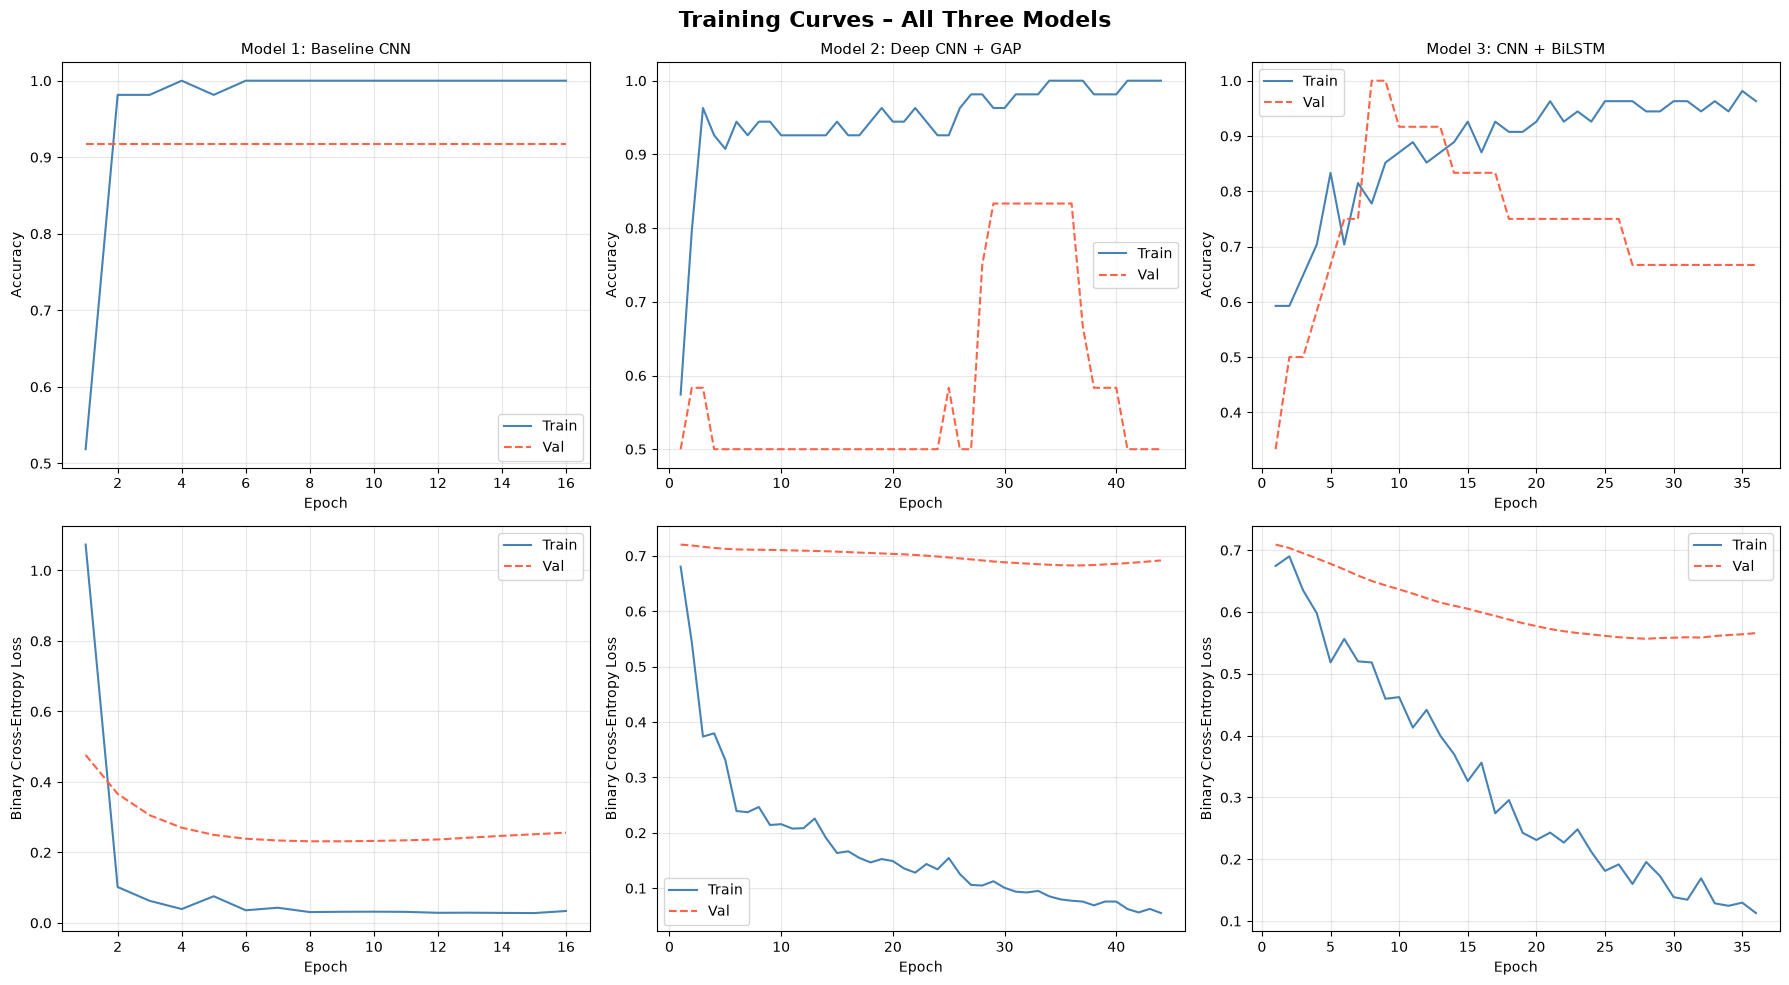

In [17]:
# Section 12: Training Curves (Accuracy & Loss)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves – All Three Models', fontsize=16, fontweight='bold')

models_info = [
    (history1, 'Model 1: Baseline CNN',    axes[0, 0], axes[1, 0]),
    (history2, 'Model 2: Deep CNN + GAP',  axes[0, 1], axes[1, 1]),
    (history3, 'Model 3: CNN + BiLSTM',    axes[0, 2], axes[1, 2]),
]

for hist, title, ax_acc, ax_loss in models_info:
    epochs_ran = range(1, len(hist.history['accuracy']) + 1)

    # Accuracy subplot
    ax_acc.plot(epochs_ran, hist.history['accuracy'], label='Train', color='steelblue')
    ax_acc.plot(epochs_ran, hist.history['val_accuracy'], label='Val', color='tomato', linestyle='--')
    ax_acc.set_title(title, fontsize=11)
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

    # Loss subplot
    ax_loss.plot(epochs_ran, hist.history['loss'], label='Train', color='steelblue')
    ax_loss.plot(epochs_ran, hist.history['val_loss'], label='Val', color='tomato', linestyle='--')
    ax_loss.set_ylabel('Binary Cross-Entropy Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

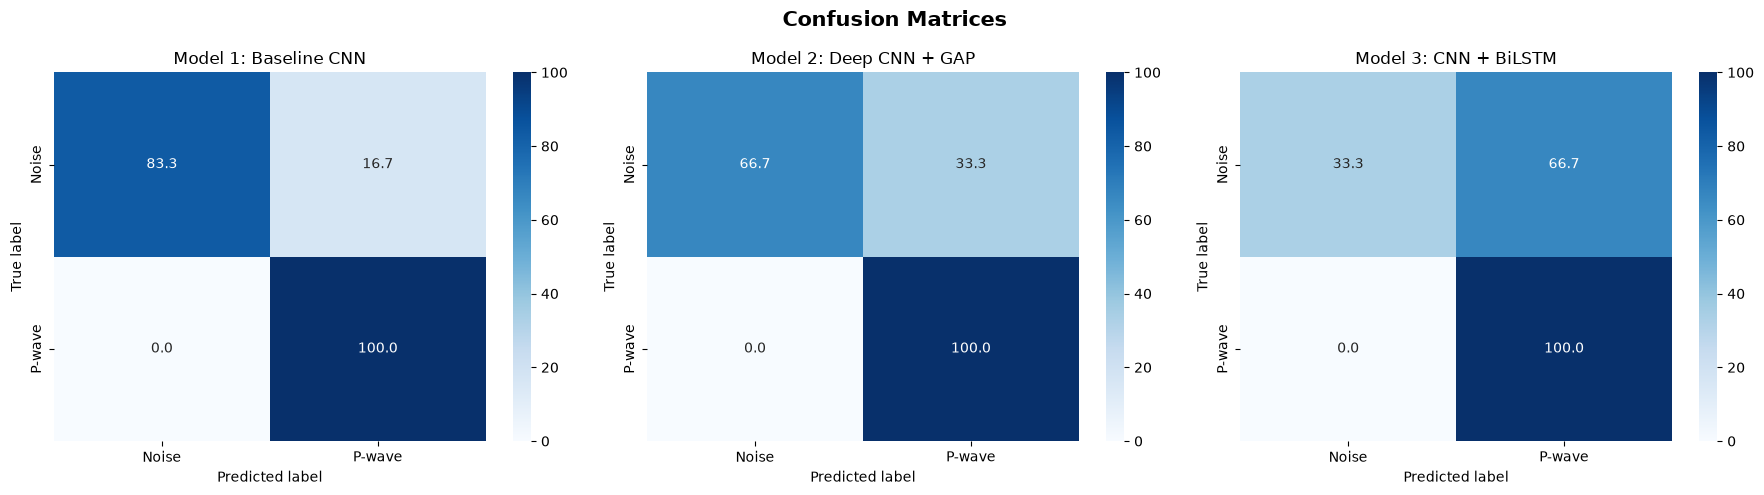

In [18]:
# Section 13: Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

preds_and_titles = [
    (y_pred1, 'Model 1: Baseline CNN'),
    (y_pred2, 'Model 2: Deep CNN + GAP'),
    (y_pred3, 'Model 3: CNN + BiLSTM')
]

for ax, (y_pred, title) in zip(axes, preds_and_titles):
    cm = confusion_matrix(y_test, y_pred)

    # Normalize to percentages for straightforward comparison
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
        xticklabels=['Noise', 'P-wave'],
        yticklabels=['Noise', 'P-wave']
    )
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


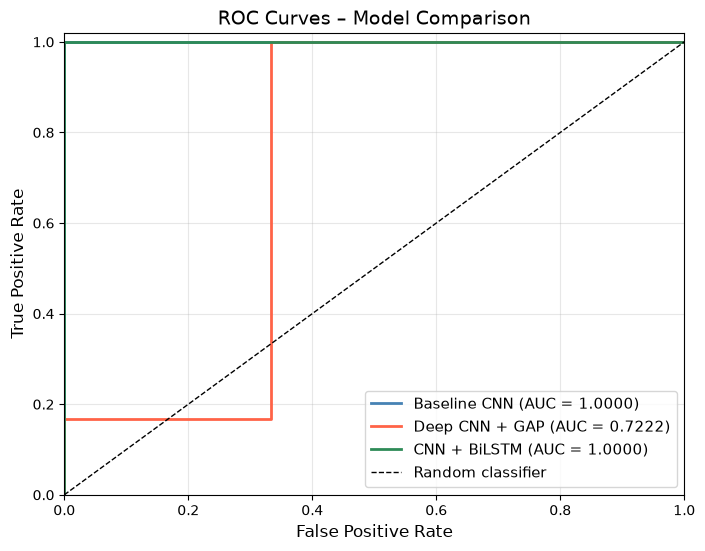

In [19]:
# Section 14: ROC Curves & AUC

plt.figure(figsize=(8, 6))

models_roc = [
    (y_prob1, 'Baseline CNN', 'steelblue'),
    (y_prob2, 'Deep CNN + GAP', 'tomato'),
    (y_prob3, 'CNN + BiLSTM', 'seagreen')
]

for y_prob, label, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.4f})')

# Diagonal reference line for a random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – Model Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Section 15: Classification Reports (Precision / Recall / F1)

models_reports = [
    ('Model 1 – Baseline CNN', y_pred1),
    ('Model 2 – Deep CNN + GAP', y_pred2),
    ('Model 3 – CNN + BiLSTM', y_pred3),
]

for model_name, y_pred in models_reports:
    print(f"\n{'=' * 55}")
    print(f"  {model_name}")
    print(f"{'=' * 55}")
    print(classification_report(y_test, y_pred, target_names=['Noise', 'P-wave']))


  Model 1 – Baseline CNN
              precision    recall  f1-score   support

       Noise       1.00      0.83      0.91         6
      P-wave       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12


  Model 2 – Deep CNN + GAP
              precision    recall  f1-score   support

       Noise       1.00      0.67      0.80         6
      P-wave       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12


  Model 3 – CNN + BiLSTM
              precision    recall  f1-score   support

       Noise       1.00      0.33      0.50         6
      P-wave       0.60      1.00      0.75         6

    accuracy                           0.67        12
   macro avg       0.80      0.67      0.62     

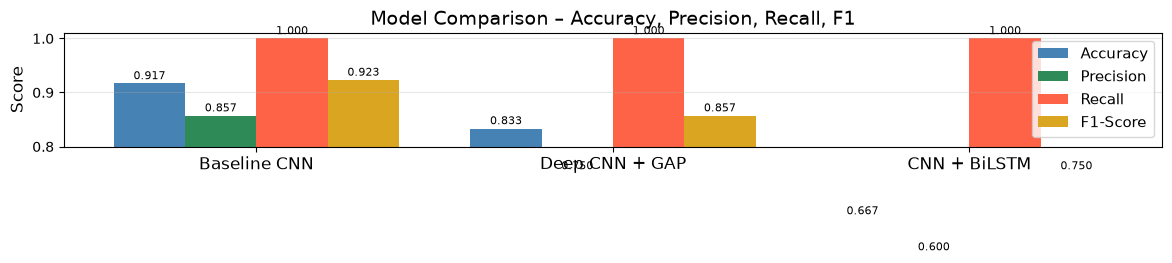

In [21]:
# Section 16: Model Comparison Bar Chart

from sklearn.metrics import f1_score, precision_score, recall_score

model_names = ['Baseline CNN', 'Deep CNN + GAP', 'CNN + BiLSTM']
accs = [acc1, acc2, acc3]
f1s = [f1_score(y_test, p) for p in [y_pred1, y_pred2, y_pred3]]
recalls = [recall_score(y_test, p) for p in [y_pred1, y_pred2, y_pred3]]
precisions = [precision_score(y_test, p) for p in [y_pred1, y_pred2, y_pred3]]

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
bars = [
    ax.bar(x - 1.5 * width, accs, width, label='Accuracy', color='steelblue'),
    ax.bar(x - 0.5 * width, precisions, width, label='Precision', color='seagreen'),
    ax.bar(x + 0.5 * width, recalls, width, label='Recall', color='tomato'),
    ax.bar(x + 1.5 * width, f1s, width, label='F1-Score', color='goldenrod'),
]

# Add text labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8
        )

# Focus the y-axis range to clearly see metric differences
ax.set_ylim(0.8, 1.01)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison – Accuracy, Precision, Recall, F1', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

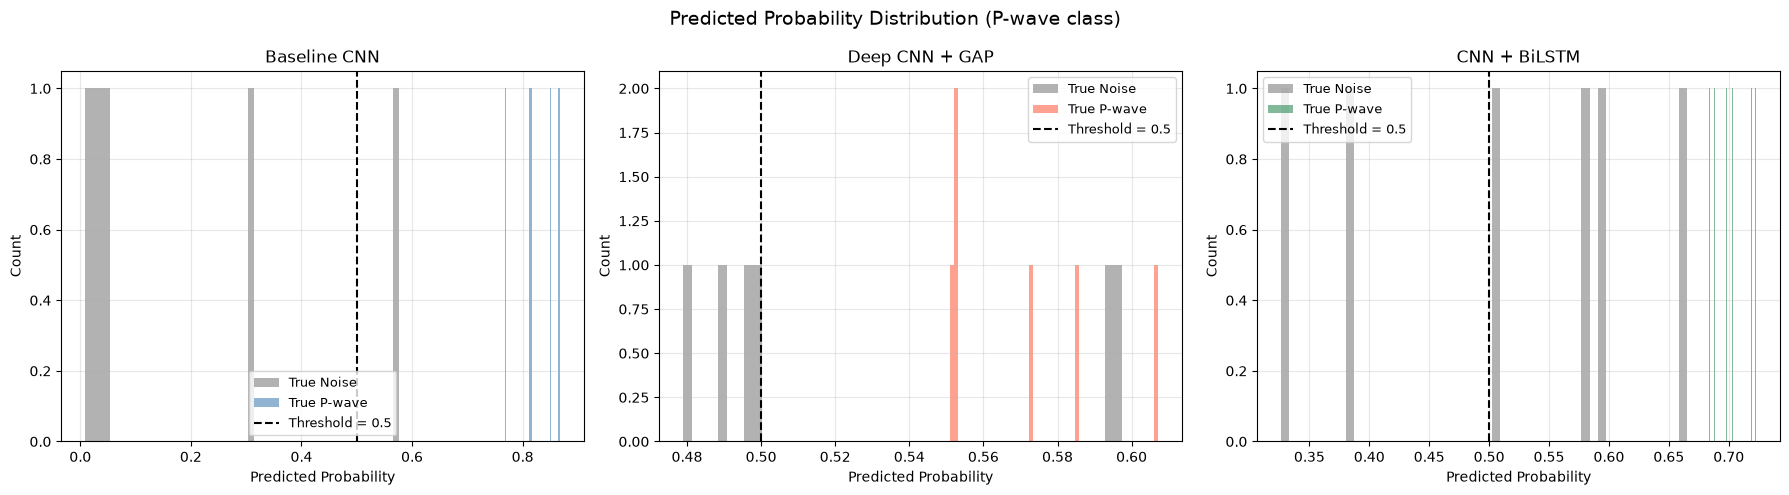

In [22]:
# Section 17: Sigmoid Output Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predicted Probability Distribution (P-wave class)', fontsize=14)

models_dist = [
    (y_prob1, 'Baseline CNN', 'steelblue'),
    (y_prob2, 'Deep CNN + GAP', 'tomato'),
    (y_prob3, 'CNN + BiLSTM', 'seagreen')
]

# Zip the axes array together with our list of model configurations
for ax, (y_prob, title, color) in zip(axes, models_dist):
    # Separate the predicted probabilities by their actual ground truth labels
    ax.hist(y_prob[y_test == 0], bins=50, alpha=0.6, color='grey', label='True Noise')
    ax.hist(y_prob[y_test == 1], bins=50, alpha=0.6, color=color, label='True P-wave')
    
    ax.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
    ax.set_title(title)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Section 18: Summary Results Table

from sklearn.metrics import roc_auc_score

# Compile all evaluation metrics into a single DataFrame for clean visualization
summary = pd.DataFrame({
    'Model': model_names,
    'Test Loss': [round(loss1, 4), round(loss2, 4), round(loss3, 4)],
    'Accuracy': [round(acc1, 4), round(acc2, 4), round(acc3, 4)],
    'Precision': [round(precision_score(y_test, p), 4) for p in [y_pred1, y_pred2, y_pred3]],
    'Recall': [round(recall_score(y_test, p), 4) for p in [y_pred1, y_pred2, y_pred3]],
    'F1-Score': [round(f1_score(y_test, p), 4) for p in [y_pred1, y_pred2, y_pred3]],
    'AUC-ROC': [round(roc_auc_score(y_test, p), 4) for p in [y_prob1, y_prob2, y_prob3]],
})

print('\n' + '=' * 70)
print('  FINAL RESULTS SUMMARY')
print('=' * 70)
print(summary.to_string(index=False))
print('=' * 70)

# Identify the top-performing architecture based on the AUC-ROC score
best_model_name = summary.loc[summary['AUC-ROC'].idxmax(), 'Model']
print(f'\n-> Best model by AUC-ROC: {best_model_name}')


  FINAL RESULTS SUMMARY
         Model  Test Loss  Accuracy  Precision  Recall  F1-Score  AUC-ROC
  Baseline CNN     0.2317    0.9167     0.8571     1.0    0.9231   1.0000
Deep CNN + GAP     0.6827    0.8333     0.7500     1.0    0.8571   0.7222
  CNN + BiLSTM     0.5566    0.6667     0.6000     1.0    0.7500   1.0000

-> Best model by AUC-ROC: Baseline CNN
